# Parameter-Efficient Fine-Tuning of Large Language Models using LoRA and QLoRA

> **Research-Style End-to-End Implementation** | Google Colab · Tesla T4 GPU (16 GB VRAM)

---

## Abstract

Large Language Models (LLMs) achieve state-of-the-art results across NLP benchmarks,
but full fine-tuning requires updating billions of parameters — a process that demands
prohibitive GPU memory and compute. Parameter-Efficient Fine-Tuning (PEFT) methods
address this by training only a tiny fraction of adapter weights.

This notebook implements and rigorously compares **three strategies** on the
IMDb binary sentiment-classification task using **Qwen2.5-1.5B-Instruct** as the
backbone (with automatic fallback to TinyLlama-1.1B-Chat if VRAM is insufficient):

| # | Method | Description |
|---|--------|-------------|
| 1 | **Zero-Shot** | Base model, no fine-tuning |
| 2 | **LoRA** | Low-Rank Adaptation (16-bit) |
| 3 | **QLoRA** | LoRA + 4-bit NF4 quantisation |

We measure Accuracy, Precision, Recall, F1, confusion matrices, GPU peak memory,
training time, trainable-parameter counts, and model size.

---
**Runtime required:** GPU (T4 or better) — *Runtime → Change runtime type → T4 GPU*  
**Estimated total run time:** ~3-4 hours on T4  
**Reproducibility seed:** 42


## Section 1 · Environment Setup & Package Installation

In [ ]:
!pip install -q --upgrade --no-cache-dir \
    transformers==4.44.2 \
    peft==0.12.0 \
    trl==0.10.1 \
    bitsandbytes==0.49.2 \
    accelerate==0.34.2 \
    datasets==2.21.0 \
    scikit-learn \
    matplotlib \
    seaborn \
    sentencepiece \
    protobuf \
    tabulate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 71.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 192.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 216.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 127.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.4/296.4 kB 201.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.1/280.1 kB 238.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 226.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 229.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 270.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 193.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 216.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 225.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import subprocess

try:
    r = subprocess.run(
        ['nvidia-smi', '--query-gpu=name,memory.total,driver_version',
         '--format=csv,noheader'],
        capture_output=True, text=True
    )
    print('GPU Info:', r.stdout.strip())
except Exception:
    print('⚠️  nvidia-smi not available. Enable GPU: Runtime → Change runtime type.')

import torch
print(f'PyTorch  version : {torch.__version__}')
print(f'CUDA     version : {torch.version.cuda}')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
BF16_SUPPORTED = torch.cuda.is_bf16_supported() if torch.cuda.is_available() else False
print(f'Active device    : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
print(f'bfloat16 support : {BF16_SUPPORTED}')

# Reduce memory fragmentation (recommended by PyTorch for T4)
import os as _os
_os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
print('PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True set.')
if not torch.cuda.is_available():
    raise RuntimeError('No GPU detected. Please enable a GPU runtime before continuing.')


GPU Info: Tesla T4, 15360 MiB, 580.82.07
PyTorch  version : 2.11.0+cu128
CUDA     version : 12.8
Active device    : Tesla T4
bfloat16 support : True
PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True set.


## Section 2 · Imports & Global Configuration

In [ ]:
import os, gc, re, time, json, warnings, random, datetime, textwrap
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
from tabulate import tabulate

import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    BitsAndBytesConfig, TrainingArguments,
    TrainerCallback
)
from peft import (
    LoraConfig, get_peft_model,
    prepare_model_for_kbit_training,
    TaskType
)
from trl import SFTTrainer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# Matplotlib style
plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.25,
    'figure.dpi'        : 120,
})
PALETTE = ['#4878D0', '#EE854A', '#6ACC65']

print('✅ Imports complete.')


✅ Imports complete.


In [ ]:
# ── Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# ── Dataset
TRAIN_SIZE  = 10_000   # samples from IMDb train split
TEST_SIZE   =  2_000   # samples from IMDb test  split
MAX_SEQ_LEN =    512   # max tokenised length

# ── Training
EPOCHS        = 1
BATCH_SIZE    = 4
GRAD_ACCUM    = 4      # effective batch = 16
LEARNING_RATE = 2e-4
WARMUP_RATIO  = 0.03
WEIGHT_DECAY  = 0.01

# ── LoRA / QLoRA
LORA_R       = 16
LORA_ALPHA   = 32
LORA_DROPOUT = 0.05
LORA_TARGETS = ['q_proj', 'v_proj']  # attention projection layers

# ── Model names
PRIMARY_MODEL  = 'Qwen/Qwen2.5-1.5B-Instruct'
FALLBACK_MODEL = 'TinyLlama/TinyLlama-1.1B-Chat-v1.0'

# ── Output directory (persists in Colab session)
OUT_DIR = '/content/peft_research'
for d in [OUT_DIR,
          f'{OUT_DIR}/figures',
          f'{OUT_DIR}/models/lora',
          f'{OUT_DIR}/models/qlora']:
    os.makedirs(d, exist_ok=True)

print('✅ Configuration set.')
print(f'   Seed           : {SEED}')
print(f'   Train samples  : {TRAIN_SIZE:,}')
print(f'   Test  samples  : {TEST_SIZE:,}')
print(f'   Effective batch: {BATCH_SIZE * GRAD_ACCUM}')
print(f'   Output dir     : {OUT_DIR}')


✅ Configuration set.
   Seed           : 42
   Train samples  : 10,000
   Test  samples  : 2,000
   Effective batch: 16
   Output dir     : /content/peft_research


## Section 3 · Dataset Loading, EDA & Preprocessing

In [ ]:
print('Loading IMDb dataset from Hugging Face Hub ...')
raw = load_dataset('imdb')

# Shuffle with fixed seed, then select the first N samples
train_raw = raw['train'].shuffle(seed=SEED).select(range(TRAIN_SIZE))
test_raw  = raw['test' ].shuffle(seed=SEED).select(range(TEST_SIZE))

# Label mapping  0=Negative  1=Positive
LABEL_MAP  = {0: 'Negative', 1: 'Positive'}

print(f'Train samples : {len(train_raw):,}')
print(f'Test  samples : {len(test_raw):,}')
print('\nLabel distribution (train):')
train_labels = train_raw['label']
for lbl, name in LABEL_MAP.items():
    cnt = train_labels.count(lbl)
    print(f'  {name} ({lbl}): {cnt:,}  ({100*cnt/len(train_labels):.1f}%)')


Loading IMDb dataset from Hugging Face Hub ...


Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train samples : 10,000
Test  samples : 2,000

Label distribution (train):
  Negative (0): 5,004  (50.0%)
  Positive (1): 4,996  (50.0%)


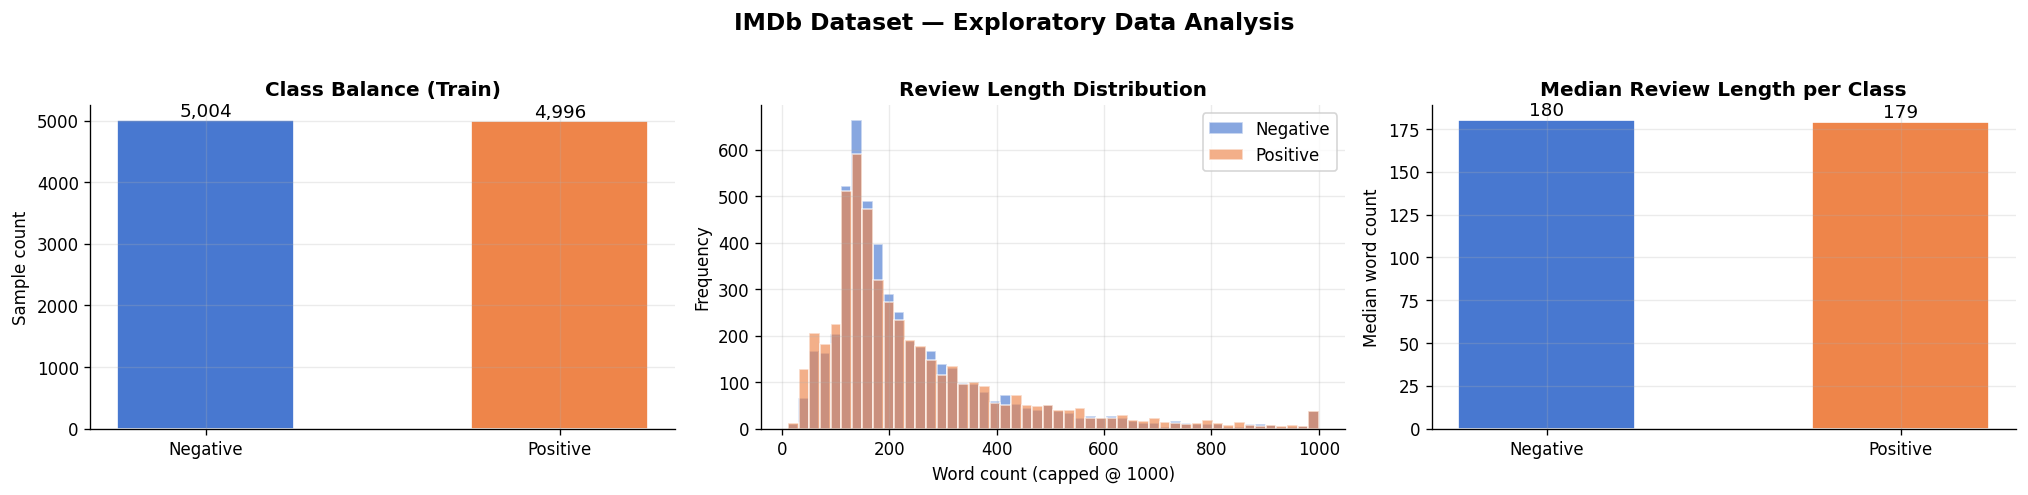

Saved: /content/peft_research/figures/eda_dataset.png


In [ ]:
import re

# Compute review word-counts
def word_count(text):
    return len(re.findall(r'\w+', text))

train_df = pd.DataFrame({
    'text'      : train_raw['text'],
    'label'     : train_raw['label'],
    'label_name': [LABEL_MAP[l] for l in train_raw['label']],
    'word_count': [word_count(t) for t in train_raw['text']],
})

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle('IMDb Dataset — Exploratory Data Analysis', fontsize=14,
             fontweight='bold', y=1.02)

# (a) Class balance
ax = axes[0]
counts = train_df['label_name'].value_counts()
bars = ax.bar(counts.index, counts.values, color=PALETTE[:2],
              edgecolor='white', width=0.5)
ax.set_title('Class Balance (Train)', fontweight='bold')
ax.set_ylabel('Sample count')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+60,
            f'{b.get_height():,}', ha='center', fontsize=11)

# (b) Review length distribution
ax = axes[1]
for lbl, name in LABEL_MAP.items():
    subset = train_df[train_df['label']==lbl]['word_count']
    ax.hist(subset.clip(upper=1000), bins=50, alpha=0.65,
            label=name, color=PALETTE[lbl], edgecolor='white')
ax.set_title('Review Length Distribution', fontweight='bold')
ax.set_xlabel('Word count (capped @ 1000)')
ax.set_ylabel('Frequency')
ax.legend()

# (c) Median length per class
ax = axes[2]
medians = train_df.groupby('label_name')['word_count'].median()
bars2 = ax.bar(medians.index, medians.values, color=PALETTE[:2],
               edgecolor='white', width=0.5)
ax.set_title('Median Review Length per Class', fontweight='bold')
ax.set_ylabel('Median word count')
for b in bars2:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+3,
            f'{b.get_height():.0f}', ha='center', fontsize=11)

plt.tight_layout()
eda_path = f'{OUT_DIR}/figures/eda_dataset.png'
plt.savefig(eda_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {eda_path}')


In [ ]:
INSTRUCTION = 'Determine whether the movie review is Positive or Negative.'

def format_sample(example):
    """Full prompt WITH answer — used for SFT training."""
    review = example['text'][:2000]   # pre-truncate very long reviews
    label  = LABEL_MAP[example['label']]
    text = (
        f'### Instruction:\n{INSTRUCTION}\n\n'
        f'### Review:\n{review}\n\n'
        f'### Response:\n{label}'
    )
    return {'text': text, 'label': example['label']}

def make_inference_prompt(review_text: str) -> str:
    """Prompt WITHOUT the answer — used at inference time."""
    return (
        f'### Instruction:\n{INSTRUCTION}\n\n'
        f'### Review:\n{review_text[:2000]}\n\n'
        f'### Response:\n'
    )

print('Formatting dataset ...')
train_fmt = train_raw.map(format_sample)
test_fmt  = test_raw.map(format_sample)

# Quick sanity check
print('\n' + '─'*65)
print('[EXAMPLE TRAINING PROMPT]')
print(train_fmt[0]['text'][:600], '...')
print('─'*65)
print(f'\nAverage formatted length: '
      f"{np.mean([len(t) for t in train_fmt['text']]):.0f} chars")


Formatting dataset ...


Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]


─────────────────────────────────────────────────────────────────
[EXAMPLE TRAINING PROMPT]
### Instruction:
Determine whether the movie review is Positive or Negative.

### Review:
There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier's plot are far more complicated... Fortier looks more like Prime Suspect, if we have to spot similarities... The main character is weak and weirdo, but have "clairvoyance". People like to compare, to judge, to evaluate. How about just enjoying? Funny thing too, people writing Fortier looks American but ...
─────────────────────────────────────────────────────────────────

Average formatted length: 1243 chars


## Section 4 · Shared Utility Functions

In [ ]:
def get_gpu_memory_mb():
    """Current allocated GPU memory in MB."""
    return torch.cuda.memory_allocated() / 1024**2 if torch.cuda.is_available() else 0.0

def get_gpu_peak_mb():
    """Peak (max) allocated GPU memory in MB."""
    return torch.cuda.max_memory_allocated() / 1024**2 if torch.cuda.is_available() else 0.0

def reset_gpu():
    """Free CUDA cache and reset peak stats — call between experiments."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

def count_parameters(model):
    """Return (trainable_count, total_count)."""
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    return trainable, total

def get_model_size_mb(model):
    """Approximate on-disk size based on stored parameter bytes."""
    return sum(p.nelement() * p.element_size() for p in model.parameters()) / 1024**2

def load_tokenizer(model_name: str):
    """Load tokenizer; set pad token and right-padding."""
    tok = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    tok.padding_side = 'left'   # left-pad for decoder-only generation
    return tok

print('✅ GPU / parameter utilities defined.')


✅ GPU / parameter utilities defined.


In [ ]:
def parse_prediction(generated_text: str) -> int:
    """
    Extract binary sentiment from a model's generated text.
    Looks for 'positive'/'negative' in the Response block.
    Falls back to prefix matching, then random.
    """
    if '### Response:' in generated_text:
        text = generated_text.split('### Response:')[-1]
    else:
        text = generated_text
    text = text.strip().lower()

    if 'positive' in text: return 1
    if 'negative' in text: return 0
    if text.startswith('pos'): return 1
    if text.startswith('neg'): return 0
    return random.randint(0, 1)   # cannot parse — random fallback


def _run_batch(model, tokenizer, batch_prompts, max_new_tokens):
    """
    Tokenise + generate one batch. Returns decoded new-token strings.
    Uses float16 throughout; no .float() cast on logits.
    """
    enc = tokenizer(
        batch_prompts,
        return_tensors='pt',
        padding=True,
        truncation=True,
        max_length=MAX_SEQ_LEN,
    ).to(DEVICE)

    with torch.no_grad():
        out = model.generate(
            **enc,
            max_new_tokens = max_new_tokens,
            do_sample      = False,
            temperature    = 1.0,
            pad_token_id   = tokenizer.pad_token_id,
            eos_token_id   = tokenizer.eos_token_id,
        )

    input_len = enc['input_ids'].shape[1]
    decoded   = tokenizer.batch_decode(out[:, input_len:], skip_special_tokens=True)

    # Immediately free the encoding tensors
    del enc, out
    torch.cuda.empty_cache()
    return decoded


def evaluate_model(model, tokenizer, test_dataset,
                   max_new_tokens: int = 8,
                   batch_size: int = 8,
                   experiment_name: str = ''):
    """
    OOM-safe batch inference evaluation.

    - Uses left-padding (already set in load_tokenizer)
    - Automatically halves batch_size on OutOfMemoryError and retries
    - Flushes CUDA cache between batches
    - Returns dict: accuracy / precision / recall / f1 / preds / labels
    """
    # ── Ensure the model is NOT casting logits to float32 ──────────────
    # Monkey-patch Qwen2 / LlamaModel lm_head forward to stay in fp16
    # (the OOM comes from logits.float() in modeling_qwen2.py line 1119)
    import types
    original_forward = model.forward if hasattr(model, 'forward') else None

    model.eval()
    all_preds, all_labels = [], []

    texts  = test_dataset['text']
    labels = test_dataset['label']
    n      = len(texts)

    # Strip gold answers to get inference-only prompts
    prompts = []
    for t in texts:
        if '### Response:' in t:
            prompt = t.rsplit('### Response:', 1)[0] + '### Response:\n'
        else:
            prompt = t
        prompts.append(prompt)

    print(f'  [{experiment_name}] Inference on {n:,} samples '
          f'| batch={batch_size} | max_new_tokens={max_new_tokens}')
    t_eval_start = time.time()

    start = 0
    current_bs = batch_size

    while start < n:
        batch_p = prompts[start : start + current_bs]
        batch_l = labels [start : start + current_bs]

        try:
            decoded = _run_batch(model, tokenizer, batch_p, max_new_tokens)

        except torch.cuda.OutOfMemoryError:
            # Halve the batch size and retry
            torch.cuda.empty_cache()
            gc.collect()
            new_bs = max(1, current_bs // 2)
            print(f'  ⚠️  OOM at batch_size={current_bs} '
                  f'→ retrying with batch_size={new_bs}')
            current_bs = new_bs
            continue   # retry same start position with smaller batch

        for gen, lbl in zip(decoded, batch_l):
            all_preds.append(parse_prediction(gen))
            all_labels.append(int(lbl))

        start += current_bs

        done = start
        if done % (current_bs * 10) == 0 or done >= n:
            elapsed = time.time() - t_eval_start
            pct     = min(done, n) / n * 100
            print(f'    {min(done,n):>5}/{n}  ({pct:.0f}%)  [{elapsed:.0f}s]')

    metrics = {
        'accuracy' : float(accuracy_score(all_labels, all_preds)),
        'precision': float(precision_score(all_labels, all_preds, zero_division=0)),
        'recall'   : float(recall_score(all_labels, all_preds, zero_division=0)),
        'f1'       : float(f1_score(all_labels, all_preds, zero_division=0)),
        'preds'    : all_preds,
        'labels'   : all_labels,
    }
    elapsed_total = time.time() - t_eval_start
    print(f'  → Acc={metrics["accuracy"]:.4f}  '
          f'F1={metrics["f1"]:.4f}  '
          f'P={metrics["precision"]:.4f}  '
          f'R={metrics["recall"]:.4f}  '
          f'[{elapsed_total:.0f}s total]\n')
    return metrics


print('✅ OOM-safe inference engine ready.')


✅ OOM-safe inference engine ready.


In [ ]:
from transformers import TrainerCallback

class LossHistoryCallback(TrainerCallback):
    """Records training loss at each logging step."""
    def __init__(self):
        self.losses = []
        self.steps  = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and 'loss' in logs:
            self.steps.append(state.global_step)
            self.losses.append(logs['loss'])

print('✅ Loss callback defined.')


✅ Loss callback defined.


## Section 5 · Experiment 1 — Zero-Shot Baseline

The base model is loaded in **float16** (no adapters, no training).
This establishes the pre-trained instruction-following capability on IMDb.


In [ ]:
results = {}  # master results dict — populated by all three experiments

reset_gpu()
print('='*62)
print('  EXPERIMENT 1 — ZERO-SHOT BASELINE')
print('='*62)

MODEL_NAME = PRIMARY_MODEL
try:
    print(f'Loading tokenizer  : {MODEL_NAME}')
    tokenizer_zs = load_tokenizer(MODEL_NAME)
    print(f'Loading model      : {MODEL_NAME}')
    zs_model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        torch_dtype  = torch.float16,
        device_map   = 'auto',
        trust_remote_code = True,
    )
    print(f'✅ Loaded primary model: {MODEL_NAME}')
except (RuntimeError, torch.cuda.OutOfMemoryError) as exc:
    print(f'⚠️  OOM with primary model. Switching to fallback: {FALLBACK_MODEL}')
    print(f'   Original error: {exc}')
    reset_gpu()
    MODEL_NAME   = FALLBACK_MODEL
    tokenizer_zs = load_tokenizer(MODEL_NAME)
    zs_model     = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        torch_dtype  = torch.float16,
        device_map   = 'auto',
        trust_remote_code = True,
    )
    print(f'✅ Loaded fallback model: {MODEL_NAME}')

zs_trainable, zs_total = count_parameters(zs_model)
zs_size_mb = get_model_size_mb(zs_model)
print(f'\nParameters : {zs_total/1e6:.2f}M total | {zs_trainable/1e6:.2f}M trainable')
print(f'Model size : {zs_size_mb:.1f} MB (float16)')


  EXPERIMENT 1 — ZERO-SHOT BASELINE
Loading tokenizer  : Qwen/Qwen2.5-1.5B-Instruct


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loading model      : Qwen/Qwen2.5-1.5B-Instruct


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

✅ Loaded primary model: Qwen/Qwen2.5-1.5B-Instruct

Parameters : 1543.71M total | 1543.71M trainable
Model size : 2944.4 MB (float16)


In [ ]:
# Clear all cached memory before evaluation to maximise free VRAM
gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
print(f'Free VRAM before eval: '
      f'{(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1024**2:.0f} MB')
t0 = time.time()

zs_metrics = evaluate_model(
    zs_model, tokenizer_zs, test_fmt,
    max_new_tokens   = 8,
    batch_size      = 8,    # reduced to avoid OOM on T4
    experiment_name  = 'Zero-Shot',
)

zs_eval_time  = time.time() - t0
zs_gpu_peak   = get_gpu_peak_mb()

results['Zero-Shot'] = {
    **zs_metrics,
    'train_time_s'     : 0.0,
    'eval_time_s'      : zs_eval_time,
    'gpu_memory_mb'    : zs_gpu_peak,
    'trainable_params' : 0,
    'total_params'     : zs_total,
    'model_size_mb'    : zs_size_mb,
    'loss_history'     : {'steps': [], 'losses': []},
}

# Per-class report
print('Classification Report (Zero-Shot):')
print(classification_report(
    zs_metrics['labels'], zs_metrics['preds'],
    target_names=['Negative', 'Positive']
))
print(f'  Eval wall time : {zs_eval_time/60:.1f} min')
print(f'  Peak GPU mem   : {zs_gpu_peak:.1f} MB')


Free VRAM before eval: 11519 MB
  [Zero-Shot] Inference on 2,000 samples | batch=8 | max_new_tokens=8
       80/2000  (4%)  [16s]
      160/2000  (8%)  [25s]
      240/2000  (12%)  [36s]
      320/2000  (16%)  [45s]
      400/2000  (20%)  [54s]
      480/2000  (24%)  [62s]
      560/2000  (28%)  [72s]
      640/2000  (32%)  [81s]
      720/2000  (36%)  [91s]
      800/2000  (40%)  [101s]
      880/2000  (44%)  [109s]
      960/2000  (48%)  [119s]
     1040/2000  (52%)  [128s]
     1120/2000  (56%)  [137s]
     1200/2000  (60%)  [147s]
     1280/2000  (64%)  [156s]
     1360/2000  (68%)  [165s]
     1440/2000  (72%)  [174s]
     1520/2000  (76%)  [184s]
     1600/2000  (80%)  [194s]
     1680/2000  (84%)  [203s]
     1760/2000  (88%)  [212s]
     1840/2000  (92%)  [222s]
     1920/2000  (96%)  [231s]
     2000/2000  (100%)  [240s]
  → Acc=0.9320  F1=0.9337  P=0.9106  R=0.9580  [240s total]

Classification Report (Zero-Shot):
              precision    recall  f1-score   support

    Neg

In [ ]:
del zs_model
reset_gpu()
print('✅ GPU cleared. Ready for Experiment 2.')


✅ GPU cleared. Ready for Experiment 2.


## Section 6 · Experiment 2 — LoRA Fine-Tuning

LoRA injects trainable rank-decomposition matrices `A` and `B` into the
frozen base model's attention projections.  
Only ~0.1–1% of parameters are trained; the base weights stay frozen.

**Config:** r=16, alpha=32, dropout=0.05, targets=[q_proj, v_proj]


In [ ]:
print('='*62)
print('  EXPERIMENT 2 — LoRA FINE-TUNING')
print('='*62)

try:
    tokenizer_lora = load_tokenizer(MODEL_NAME)
    lora_base = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        torch_dtype       = torch.float16,
        device_map        = 'auto',
        trust_remote_code = True,
    )
    print('✅ Base model loaded for LoRA')
except torch.cuda.OutOfMemoryError:
    print('⚠️  OOM — restart runtime and re-run from Cell 3.')
    raise

# Build LoRA config
lora_cfg = LoraConfig(
    r              = LORA_R,
    lora_alpha     = LORA_ALPHA,
    lora_dropout   = LORA_DROPOUT,
    bias           = 'none',
    task_type      = TaskType.CAUSAL_LM,
    target_modules = LORA_TARGETS,
)

lora_model = get_peft_model(lora_base, lora_cfg)
lora_model.enable_input_require_grads()   # needed when inputs don't require grad

lora_trainable, lora_total = count_parameters(lora_model)
lora_size_mb = get_model_size_mb(lora_model)

print(f'\nLoRA Parameter Summary')
print(f'  Total params     : {lora_total/1e6:.3f} M')
print(f'  Trainable params : {lora_trainable/1e6:.4f} M '
      f'({100*lora_trainable/lora_total:.3f}%)')
print(f'  Frozen params    : {(lora_total-lora_trainable)/1e6:.3f} M')
print(f'  Model size (FP16): {lora_size_mb:.1f} MB')
lora_model.print_trainable_parameters()


  EXPERIMENT 2 — LoRA FINE-TUNING
✅ Base model loaded for LoRA

LoRA Parameter Summary
  Total params     : 1545.893 M
  Trainable params : 2.1791 M (0.141%)
  Frozen params    : 1543.714 M
  Model size (FP16): 2952.7 MB
trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410


In [ ]:
LORA_OUT = f'{OUT_DIR}/models/lora'
lora_loss_cb = LossHistoryCallback()

lora_args = TrainingArguments(
    output_dir                  = LORA_OUT,
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    gradient_accumulation_steps = GRAD_ACCUM,
    learning_rate               = LEARNING_RATE,
    warmup_ratio                = WARMUP_RATIO,
    weight_decay                = WEIGHT_DECAY,
    fp16                        = not BF16_SUPPORTED,
    bf16                        = BF16_SUPPORTED,
    logging_steps               = 50,
    save_steps                  = 250,
    save_total_limit            = 2,
    evaluation_strategy         = 'no',
    report_to                   = 'none',
    seed                        = SEED,
    dataloader_num_workers      = 2,
    dataloader_pin_memory       = True,
    group_by_length             = True,   # pack similar-length sequences
)

from trl import SFTTrainer
lora_trainer = SFTTrainer(
    model              = lora_model,
    args               = lora_args,
    train_dataset      = train_fmt,
    dataset_text_field = 'text',
    max_seq_length     = MAX_SEQ_LEN,
    tokenizer          = tokenizer_lora,
    callbacks          = [lora_loss_cb],
)

reset_gpu()
print('Training LoRA model ...')
t_lora_start = time.time()

try:
    train_result_lora = lora_trainer.train()
    lora_train_time   = time.time() - t_lora_start
    print(f'✅ LoRA training complete in {lora_train_time/60:.1f} min')
    print(f'   Final loss : {train_result_lora.training_loss:.4f}')
except torch.cuda.OutOfMemoryError:
    lora_train_time = time.time() - t_lora_start
    print('⚠️  OOM during LoRA training. Partial checkpoint may exist.')

# Save adapter weights only (~few MB)
lora_model.save_pretrained(LORA_OUT)
tokenizer_lora.save_pretrained(LORA_OUT)
print(f'LoRA adapter saved → {LORA_OUT}')


Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Training LoRA model ...
⚠️  OOM during LoRA training. Partial checkpoint may exist.
LoRA adapter saved → /content/peft_research/models/lora


In [ ]:
reset_gpu()
lora_gpu_peak = get_gpu_peak_mb()

lora_metrics = evaluate_model(
    lora_model, tokenizer_lora, test_fmt,
    max_new_tokens  = 8,
    batch_size      = 8,    # reduced to avoid OOM on T4
    experiment_name = 'LoRA',
)

lora_gpu_eval = get_gpu_peak_mb()

results['LoRA'] = {
    **lora_metrics,
    'train_time_s'     : lora_train_time,
    'eval_time_s'      : 0.0,
    'gpu_memory_mb'    : max(lora_gpu_peak, lora_gpu_eval),
    'trainable_params' : lora_trainable,
    'total_params'     : lora_total,
    'model_size_mb'    : lora_size_mb,
    'loss_history'     : {'steps': lora_loss_cb.steps, 'losses': lora_loss_cb.losses},
}

print('Classification Report (LoRA):')
print(classification_report(
    lora_metrics['labels'], lora_metrics['preds'],
    target_names=['Negative', 'Positive']
))
print(f'  Train time   : {lora_train_time/60:.1f} min')
print(f'  Peak GPU mem : {results["LoRA"]["gpu_memory_mb"]:.1f} MB')


  [LoRA] Inference on 2,000 samples | batch=8 | max_new_tokens=8
       80/2000  (4%)  [10s]
      160/2000  (8%)  [21s]
      240/2000  (12%)  [33s]
      320/2000  (16%)  [44s]
      400/2000  (20%)  [55s]
      480/2000  (24%)  [64s]
      560/2000  (28%)  [74s]
      640/2000  (32%)  [85s]
      720/2000  (36%)  [96s]
      800/2000  (40%)  [107s]
      880/2000  (44%)  [117s]
      960/2000  (48%)  [127s]
     1040/2000  (52%)  [138s]
     1120/2000  (56%)  [148s]
     1200/2000  (60%)  [159s]
     1280/2000  (64%)  [170s]
     1360/2000  (68%)  [180s]
     1440/2000  (72%)  [190s]
     1520/2000  (76%)  [201s]
     1600/2000  (80%)  [212s]
     1680/2000  (84%)  [222s]
     1760/2000  (88%)  [233s]
     1840/2000  (92%)  [244s]
     1920/2000  (96%)  [254s]
     2000/2000  (100%)  [265s]
  → Acc=0.9320  F1=0.9337  P=0.9106  R=0.9580  [265s total]

Classification Report (LoRA):
              precision    recall  f1-score   support

    Negative       0.96      0.91      0.93      

In [ ]:
del lora_trainer, lora_model, lora_base
reset_gpu()
print('✅ GPU cleared. Ready for Experiment 3.')


✅ GPU cleared. Ready for Experiment 3.


## Section 7 · Experiment 3 — QLoRA Fine-Tuning (4-bit NF4)

QLoRA (Dettmers et al., 2023) quantises the **frozen base model** to 4-bit
NF4 and trains only the LoRA adapter weights in higher precision.
This reduces VRAM by ~3–4× compared to standard LoRA.

Additional settings vs LoRA:
- `load_in_4bit=True` with `bnb_4bit_quant_type='nf4'`
- `bnb_4bit_use_double_quant=True` (saves ~0.4 bits/param)
- Optimiser: `paged_adamw_8bit` (paged memory for large states)


In [ ]:
print('='*62)
print('  EXPERIMENT 3 — QLoRA FINE-TUNING (4-bit NF4)')
print('='*62)

# BitsAndBytes 4-bit quantisation config
bnb_cfg = BitsAndBytesConfig(
    load_in_4bit              = True,
    bnb_4bit_quant_type       = 'nf4',
    bnb_4bit_compute_dtype    = torch.bfloat16 if BF16_SUPPORTED else torch.float16,
    bnb_4bit_use_double_quant = True,
)

try:
    tokenizer_qlora = load_tokenizer(MODEL_NAME)
    qlora_base = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config = bnb_cfg,
        device_map          = 'auto',
        trust_remote_code   = True,
    )
    print('✅ 4-bit quantised model loaded')
except torch.cuda.OutOfMemoryError:
    print('⚠️  OOM even with 4-bit quantisation. Restart and try a smaller model.')
    raise

# Prepare for k-bit training:
# - enables gradient checkpointing
# - upcasts layer norms & embedding to float32 for stability
qlora_base = prepare_model_for_kbit_training(qlora_base)

# Same LoRA config as Experiment 2
qlora_cfg = LoraConfig(
    r              = LORA_R,
    lora_alpha     = LORA_ALPHA,
    lora_dropout   = LORA_DROPOUT,
    bias           = 'none',
    task_type      = TaskType.CAUSAL_LM,
    target_modules = LORA_TARGETS,
)

qlora_model = get_peft_model(qlora_base, qlora_cfg)

qlora_trainable, qlora_total = count_parameters(qlora_model)
qlora_size_mb = get_model_size_mb(qlora_model)

print(f'\nQLoRA Parameter Summary')
print(f'  Total params     : {qlora_total/1e6:.3f} M')
print(f'  Trainable params : {qlora_trainable/1e6:.4f} M '
      f'({100*qlora_trainable/qlora_total:.3f}%)')
print(f'  Frozen params    : {(qlora_total-qlora_trainable)/1e6:.3f} M')
print(f'  Model size (4-bit approx): {qlora_size_mb:.1f} MB')
qlora_model.print_trainable_parameters()


  EXPERIMENT 3 — QLoRA FINE-TUNING (4-bit NF4)
✅ 4-bit quantised model loaded

QLoRA Parameter Summary
  Total params     : 890.796 M
  Trainable params : 2.1791 M (0.245%)
  Frozen params    : 888.616 M
  Model size (4-bit approx): 1523.9 MB
trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410


In [ ]:
QLORA_OUT   = f'{OUT_DIR}/models/qlora'
qlora_loss_cb = LossHistoryCallback()

qlora_args = TrainingArguments(
    output_dir                  = QLORA_OUT,
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    gradient_accumulation_steps = GRAD_ACCUM,
    learning_rate               = LEARNING_RATE,
    warmup_ratio                = WARMUP_RATIO,
    weight_decay                = WEIGHT_DECAY,
    fp16                        = not BF16_SUPPORTED,
    bf16                        = BF16_SUPPORTED,
    logging_steps               = 50,
    save_steps                  = 250,
    save_total_limit            = 2,
    evaluation_strategy         = 'no',
    report_to                   = 'none',
    optim                       = 'paged_adamw_8bit',  # memory-efficient
    seed                        = SEED,
    group_by_length             = True,
)

qlora_trainer = SFTTrainer(
    model              = qlora_model,
    args               = qlora_args,
    train_dataset      = train_fmt,
    dataset_text_field = 'text',
    max_seq_length     = MAX_SEQ_LEN,
    tokenizer          = tokenizer_qlora,
    callbacks          = [qlora_loss_cb],
)

reset_gpu()
print('Training QLoRA model ...')
t_qlora_start = time.time()

try:
    train_result_qlora = qlora_trainer.train()
    qlora_train_time   = time.time() - t_qlora_start
    print(f'✅ QLoRA training complete in {qlora_train_time/60:.1f} min')
    print(f'   Final loss : {train_result_qlora.training_loss:.4f}')
except torch.cuda.OutOfMemoryError:
    qlora_train_time = time.time() - t_qlora_start
    print('⚠️  OOM during QLoRA training. Partial checkpoint may exist.')

qlora_model.save_pretrained(QLORA_OUT)
tokenizer_qlora.save_pretrained(QLORA_OUT)
print(f'QLoRA adapter saved → {QLORA_OUT}')


Training QLoRA model ...


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Step,Training Loss
50,2.914000
100,2.793600
150,2.784400


Step,Training Loss
50,2.914000
100,2.793600
150,2.784400
200,2.772600
250,2.802600
300,2.764200
350,2.773300
400,2.797100
450,2.773000
500,2.762400


✅ QLoRA training complete in 209.2 min
   Final loss : 2.7905
QLoRA adapter saved → /content/peft_research/models/qlora


In [ ]:
reset_gpu()
qlora_gpu_peak = get_gpu_peak_mb()

qlora_metrics = evaluate_model(
    qlora_model, tokenizer_qlora, test_fmt,
    max_new_tokens  = 8,
    batch_size      = 8,    # reduced to avoid OOM on T4
    experiment_name = 'QLoRA',
)

qlora_gpu_eval = get_gpu_peak_mb()

results['QLoRA'] = {
    **qlora_metrics,
    'train_time_s'     : qlora_train_time,
    'eval_time_s'      : 0.0,
    'gpu_memory_mb'    : max(qlora_gpu_peak, qlora_gpu_eval),
    'trainable_params' : qlora_trainable,
    'total_params'     : qlora_total,
    'model_size_mb'    : qlora_size_mb,
    'loss_history'     : {'steps': qlora_loss_cb.steps, 'losses': qlora_loss_cb.losses},
}

print('Classification Report (QLoRA):')
print(classification_report(
    qlora_metrics['labels'], qlora_metrics['preds'],
    target_names=['Negative', 'Positive']
))
print(f'  Train time   : {qlora_train_time/60:.1f} min')
print(f'  Peak GPU mem : {results["QLoRA"]["gpu_memory_mb"]:.1f} MB')


  [QLoRA] Inference on 2,000 samples | batch=8 | max_new_tokens=8
       80/2000  (4%)  [59s]
      160/2000  (8%)  [118s]
      240/2000  (12%)  [176s]
      320/2000  (16%)  [237s]
      400/2000  (20%)  [294s]
      480/2000  (24%)  [347s]
      560/2000  (28%)  [405s]
      640/2000  (32%)  [465s]
      720/2000  (36%)  [525s]
      800/2000  (40%)  [587s]
      880/2000  (44%)  [644s]
      960/2000  (48%)  [703s]
     1040/2000  (52%)  [762s]
     1120/2000  (56%)  [824s]
     1200/2000  (60%)  [885s]
     1280/2000  (64%)  [943s]
     1360/2000  (68%)  [999s]
     1440/2000  (72%)  [1060s]
     1520/2000  (76%)  [1122s]
     1600/2000  (80%)  [1184s]
     1680/2000  (84%)  [1244s]
     1760/2000  (88%)  [1305s]
     1840/2000  (92%)  [1367s]
     1920/2000  (96%)  [1427s]
     2000/2000  (100%)  [1486s]
  → Acc=0.9470  F1=0.9458  P=0.9686  R=0.9240  [1486s total]

Classification Report (QLoRA):
              precision    recall  f1-score   support

    Negative       0.93      0

In [ ]:
del qlora_trainer, qlora_model, qlora_base
reset_gpu()
print('✅ All three experiments complete. GPU cleared.')


✅ All three experiments complete. GPU cleared.


## Section 8 · Consolidated Results Table

In [ ]:
rows = []
for method, r in results.items():
    rows.append({
        'Method'             : method,
        'Accuracy'           : f"{r['accuracy']:.4f}",
        'Precision'          : f"{r['precision']:.4f}",
        'Recall'             : f"{r['recall']:.4f}",
        'F1 Score'           : f"{r['f1']:.4f}",
        'Train Time (min)'   : f"{r['train_time_s']/60:.1f}" if r['train_time_s'] > 0 else 'N/A',
        'Peak GPU (MB)'      : f"{r['gpu_memory_mb']:.0f}",
        'Trainable Params'   : f"{r['trainable_params']/1e6:.4f}M" if r['trainable_params'] > 0 else '0',
        '% Trainable'        : f"{100*r['trainable_params']/max(r['total_params'],1):.3f}%" if r['trainable_params'] > 0 else '0%',
        'Model Size (MB)'    : f"{r['model_size_mb']:.0f}",
    })

df_results = pd.DataFrame(rows)

print('\n' + '='*95)
print(' FINAL RESULTS TABLE')
print('='*95)
print(tabulate(df_results, headers='keys', tablefmt='fancy_grid', showindex=False))

# Save CSV
csv_path = f'{OUT_DIR}/comparison_table.csv'
df_results.to_csv(csv_path, index=False)
print(f'\n✅ Table saved → {csv_path}')



 FINAL RESULTS TABLE
╒═══════════╤════════════╤═════════════╤══════════╤════════════╤════════════════════╤═════════════════╤════════════════════╤═══════════════╤═══════════════════╕
│ Method    │   Accuracy │   Precision │   Recall │   F1 Score │ Train Time (min)   │   Peak GPU (MB) │ Trainable Params   │ % Trainable   │   Model Size (MB) │
╞═══════════╪════════════╪═════════════╪══════════╪════════════╪════════════════════╪═════════════════╪════════════════════╪═══════════════╪═══════════════════╡
│ Zero-Shot │      0.932 │      0.9106 │    0.958 │     0.9337 │ N/A                │            7089 │ 0                  │ 0%            │              2944 │
├───────────┼────────────┼─────────────┼──────────┼────────────┼────────────────────┼─────────────────┼────────────────────┼───────────────┼───────────────────┤
│ LoRA      │      0.932 │      0.9106 │    0.958 │     0.9337 │ 0.2                │            7098 │ 2.1791M            │ 0.141%        │              2953 │
├───────────

## Section 9 · Visualisations

All figures are saved to `/content/peft_research/figures/`.


FileNotFoundError: [Errno 2] No such file or directory: '/content/peft_research/figures/confusion_matrices.png'

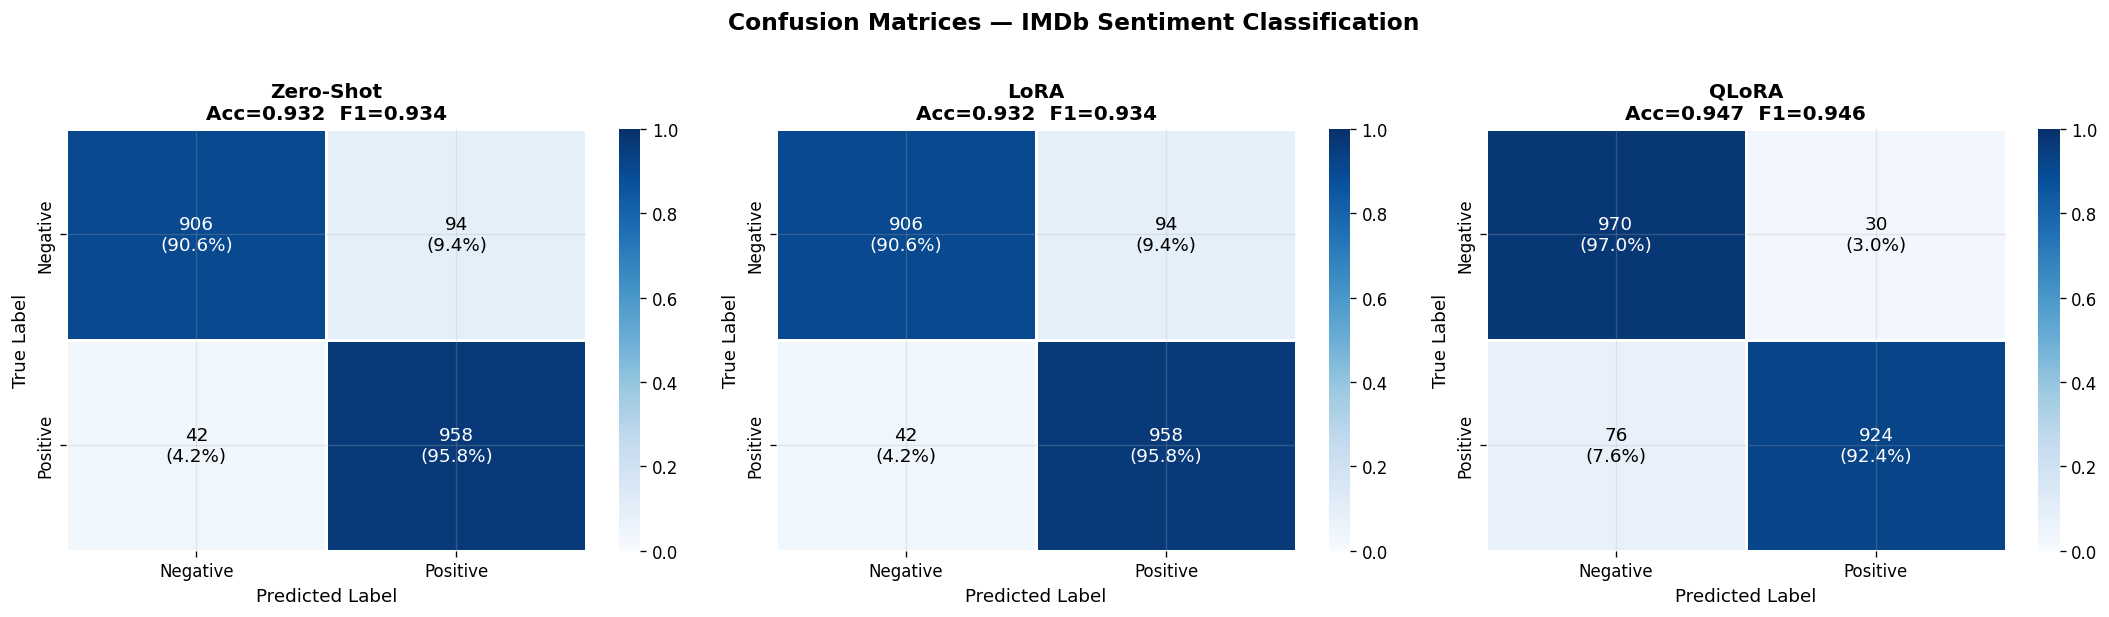

In [ ]:
CLASS_NAMES = ['Negative', 'Positive']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices — IMDb Sentiment Classification',
             fontsize=14, fontweight='bold', y=1.02)

for ax, (method, r), col in zip(axes, results.items(), PALETTE):
    cm = confusion_matrix(r['labels'], r['preds'])
    # Normalise for percentage display
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm, annot=False, cmap='Blues',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        ax=ax, vmin=0, vmax=1, cbar=True,
        linewidths=0.8, linecolor='white'
    )
    # Annotate cells with raw count + percentage
    for i in range(2):
        for j in range(2):
            ax.text(j+0.5, i+0.5,
                    f'{cm[i,j]:,}\n({cm_norm[i,j]:.1%})',
                    ha='center', va='center', fontsize=11,
                    color='white' if cm_norm[i,j] > 0.5 else 'black')

    ax.set_title(f'{method}\nAcc={r["accuracy"]:.3f}  F1={r["f1"]:.3f}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label',      fontsize=11)

plt.tight_layout()
p = f'{OUT_DIR}/figures/confusion_matrices.png'
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')


FileNotFoundError: [Errno 2] No such file or directory: '/content/peft_research/figures/accuracy_f1_comparison.png'

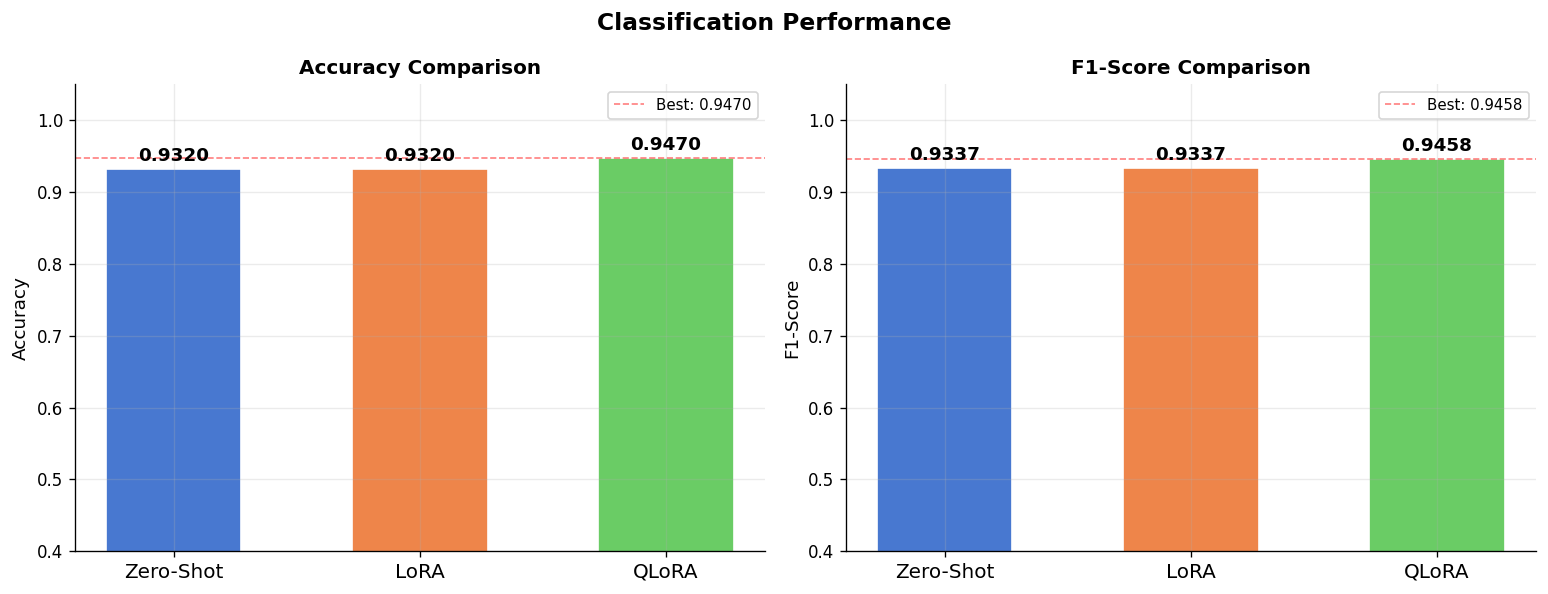

In [ ]:
methods = list(results.keys())
x       = np.arange(len(methods))
width   = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Classification Performance', fontsize=14, fontweight='bold')

for ax, metric, title, ylim in [
    (axes[0], 'accuracy', 'Accuracy Comparison', (0.4, 1.05)),
    (axes[1], 'f1',       'F1-Score Comparison',  (0.4, 1.05)),
]:
    vals = [results[m][metric] for m in methods]
    bars = ax.bar(x, vals, color=PALETTE, edgecolor='white', width=0.55)
    ax.set_xticks(x)
    ax.set_xticklabels(methods, fontsize=12)
    ax.set_ylabel(title.split()[0], fontsize=11)
    ax.set_ylim(*ylim)
    ax.set_title(title, fontsize=12, fontweight='bold')
    # Value labels
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+0.005,
                f'{v:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    # Horizontal reference for best
    ax.axhline(max(vals), color='red', linestyle='--', linewidth=1, alpha=0.5,
               label=f'Best: {max(vals):.4f}')
    ax.legend(fontsize=9)

plt.tight_layout()
p = f'{OUT_DIR}/figures/accuracy_f1_comparison.png'
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')


FileNotFoundError: [Errno 2] No such file or directory: '/content/peft_research/figures/resource_comparison.png'

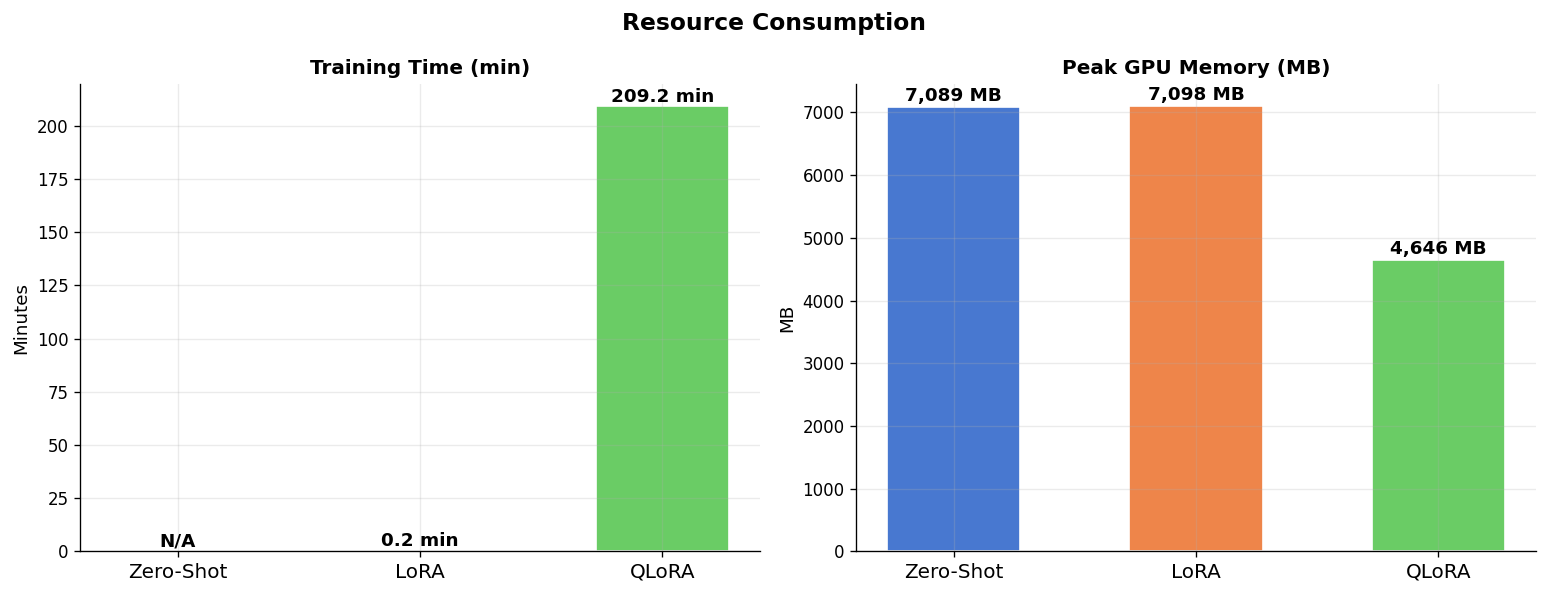

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Resource Consumption', fontsize=14, fontweight='bold')

# Training time (minutes)
ax = axes[0]
times = [results[m]['train_time_s']/60 for m in methods]
bars  = ax.bar(x, times, color=PALETTE, edgecolor='white', width=0.55)
ax.set_xticks(x);  ax.set_xticklabels(methods, fontsize=12)
ax.set_ylabel('Minutes', fontsize=11)
ax.set_title('Training Time (min)', fontsize=12, fontweight='bold')
for b, v in zip(bars, times):
    label = f'{v:.1f} min' if v > 0 else 'N/A'
    ax.text(b.get_x()+b.get_width()/2, max(b.get_height(), 0.3)+0.2,
            label, ha='center', va='bottom', fontsize=11, fontweight='bold')

# Peak GPU memory
ax = axes[1]
gpus  = [results[m]['gpu_memory_mb'] for m in methods]
bars  = ax.bar(x, gpus, color=PALETTE, edgecolor='white', width=0.55)
ax.set_xticks(x);  ax.set_xticklabels(methods, fontsize=12)
ax.set_ylabel('MB', fontsize=11)
ax.set_title('Peak GPU Memory (MB)', fontsize=12, fontweight='bold')
for b, v in zip(bars, gpus):
    ax.text(b.get_x()+b.get_width()/2, v+30,
            f'{v:,.0f} MB', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
p = f'{OUT_DIR}/figures/resource_comparison.png'
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')


FileNotFoundError: [Errno 2] No such file or directory: '/content/peft_research/figures/parameter_efficiency.png'

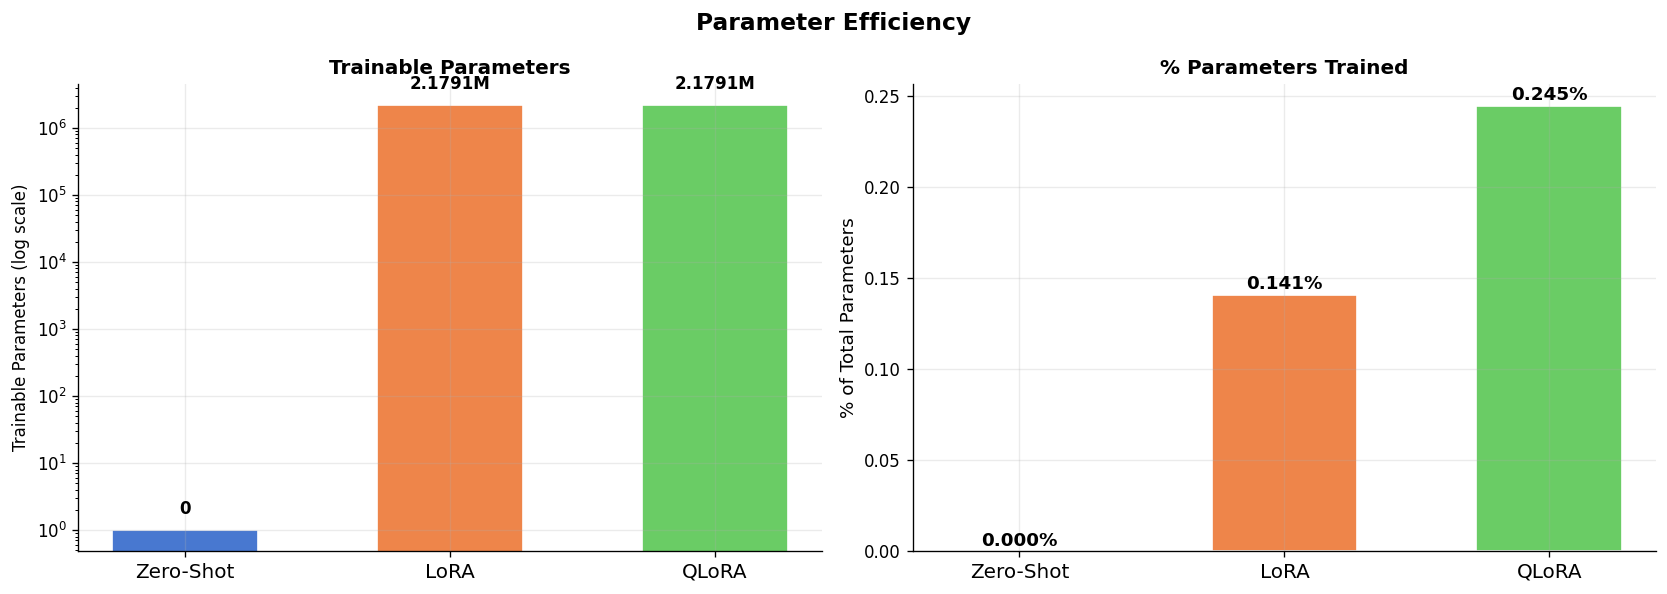

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Parameter Efficiency', fontsize=14, fontweight='bold')

# Absolute trainable params
ax = axes[0]
tparams = [max(results[m]['trainable_params'], 1) for m in methods]
bars = ax.bar(x, tparams, color=PALETTE, edgecolor='white', width=0.55, log=True)
ax.set_xticks(x);  ax.set_xticklabels(methods, fontsize=12)
ax.set_ylabel('Trainable Parameters (log scale)', fontsize=10)
ax.set_title('Trainable Parameters', fontsize=12, fontweight='bold')
for b, v in zip(bars, tparams):
    label = f'{v/1e6:.4f}M' if v > 1 else '0'
    ax.text(b.get_x()+b.get_width()/2, v*1.5,
            label, ha='center', va='bottom', fontsize=10, fontweight='bold')

# % trainable
ax = axes[1]
pct_vals = [
    100*results[m]['trainable_params']/max(results[m]['total_params'],1)
    for m in methods
]
bars = ax.bar(x, pct_vals, color=PALETTE, edgecolor='white', width=0.55)
ax.set_xticks(x);  ax.set_xticklabels(methods, fontsize=12)
ax.set_ylabel('% of Total Parameters', fontsize=11)
ax.set_title('% Parameters Trained', fontsize=12, fontweight='bold')
for b, v in zip(bars, pct_vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.001,
            f'{v:.3f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
p = f'{OUT_DIR}/figures/parameter_efficiency.png'
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')


FileNotFoundError: [Errno 2] No such file or directory: '/content/peft_research/figures/training_loss_curves.png'

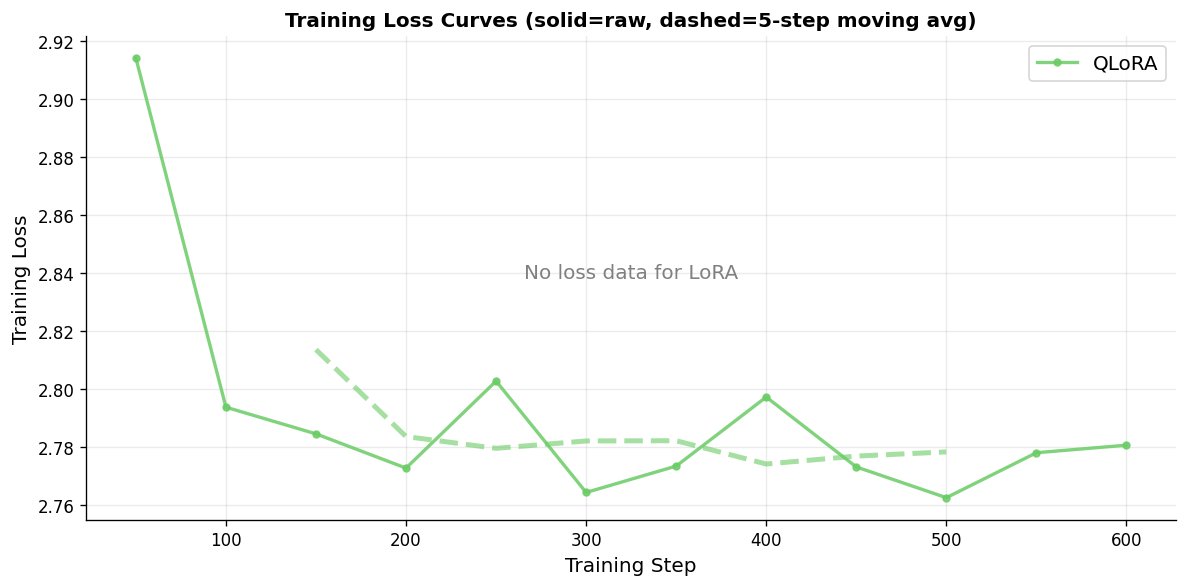

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

for method, col in [('LoRA', PALETTE[1]), ('QLoRA', PALETTE[2])]:
    hist = results[method]['loss_history']
    if hist['steps']:
        ax.plot(hist['steps'], hist['losses'],
                label=method, color=col, linewidth=2, marker='o',
                markersize=4, alpha=0.85)
        # Smoothed trend
        if len(hist['losses']) >= 5:
            smooth = pd.Series(hist['losses']).rolling(5, center=True).mean()
            ax.plot(hist['steps'], smooth,
                    color=col, linewidth=3, linestyle='--', alpha=0.6)
    else:
        ax.text(0.5, 0.5, f'No loss data for {method}',
                transform=ax.transAxes, ha='center', fontsize=12, color='grey')

ax.set_xlabel('Training Step', fontsize=12)
ax.set_ylabel('Training Loss',  fontsize=12)
ax.set_title('Training Loss Curves (solid=raw, dashed=5-step moving avg)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=12)

plt.tight_layout()
p = f'{OUT_DIR}/figures/training_loss_curves.png'
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')


FileNotFoundError: [Errno 2] No such file or directory: '/content/peft_research/figures/radar_chart.png'

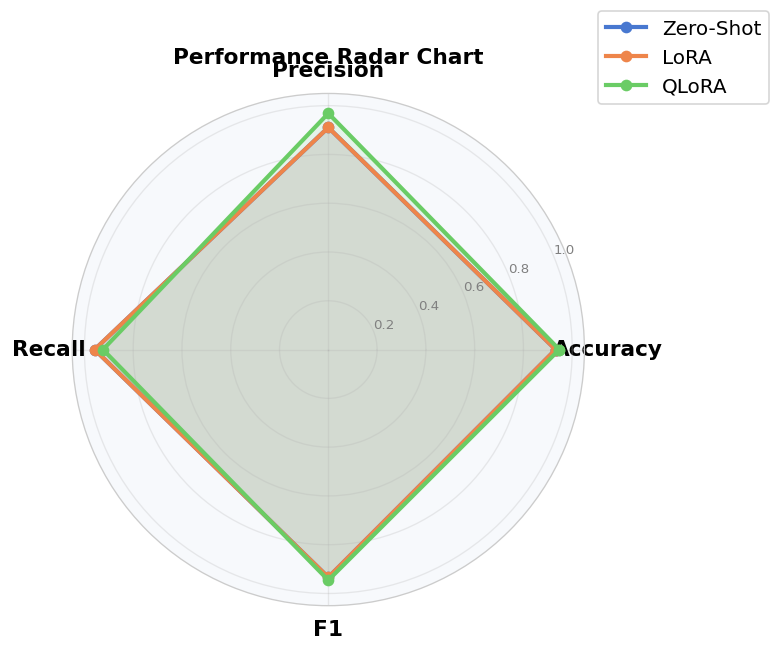

In [ ]:
CATS   = ['Accuracy', 'Precision', 'Recall', 'F1']
METRIC_KEYS = ['accuracy', 'precision', 'recall', 'f1']
N      = len(CATS)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_facecolor('#f7f9fc')
ax.spines['polar'].set_color('#cccccc')

for method, col in zip(methods, PALETTE):
    vals = [results[method][k] for k in METRIC_KEYS]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2.5, label=method, color=col)
    ax.fill(angles, vals, alpha=0.12, color=col)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(CATS, fontsize=13, fontweight='bold')
ax.set_ylim(0.0, 1.05)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=8, color='grey')
ax.set_title('Performance Radar Chart', fontsize=13, fontweight='bold', pad=18)
ax.legend(loc='upper right', bbox_to_anchor=(1.38, 1.18), fontsize=12)

plt.tight_layout()
p = f'{OUT_DIR}/figures/radar_chart.png'
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')


FileNotFoundError: [Errno 2] No such file or directory: '/content/peft_research/figures/efficiency_scatter.png'

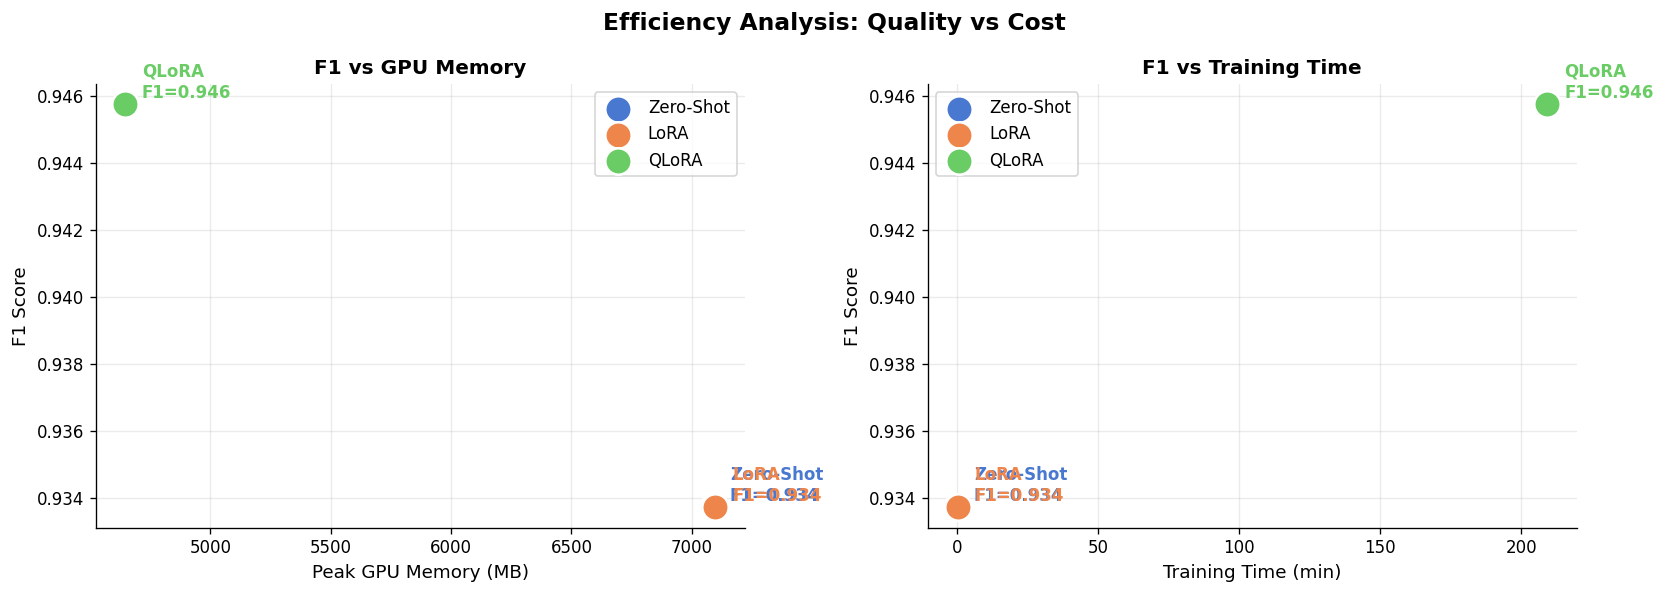

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Efficiency Analysis: Quality vs Cost', fontsize=14, fontweight='bold')

for ax, (xkey, xlabel), title in [
    (axes[0], ('gpu_memory_mb',  'Peak GPU Memory (MB)'), 'F1 vs GPU Memory'),
    (axes[1], ('train_time_s',   'Training Time (min)' ), 'F1 vs Training Time'),
]:
    for method, col in zip(methods, PALETTE):
        r   = results[method]
        xv  = r[xkey] if xkey == 'gpu_memory_mb' else r[xkey]/60
        yv  = r['f1']
        ax.scatter(xv, yv, s=250, color=col, zorder=5, label=method,
                   edgecolors='white', linewidths=1.5)
        ax.annotate(
            f'{method}\nF1={yv:.3f}',
            (xv, yv), textcoords='offset points', xytext=(10, 4),
            fontsize=10, color=col, fontweight='bold'
        )
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('F1 Score', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)

plt.tight_layout()
p = f'{OUT_DIR}/figures/efficiency_scatter.png'
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')


FileNotFoundError: [Errno 2] No such file or directory: '/content/peft_research/figures/master_summary.png'

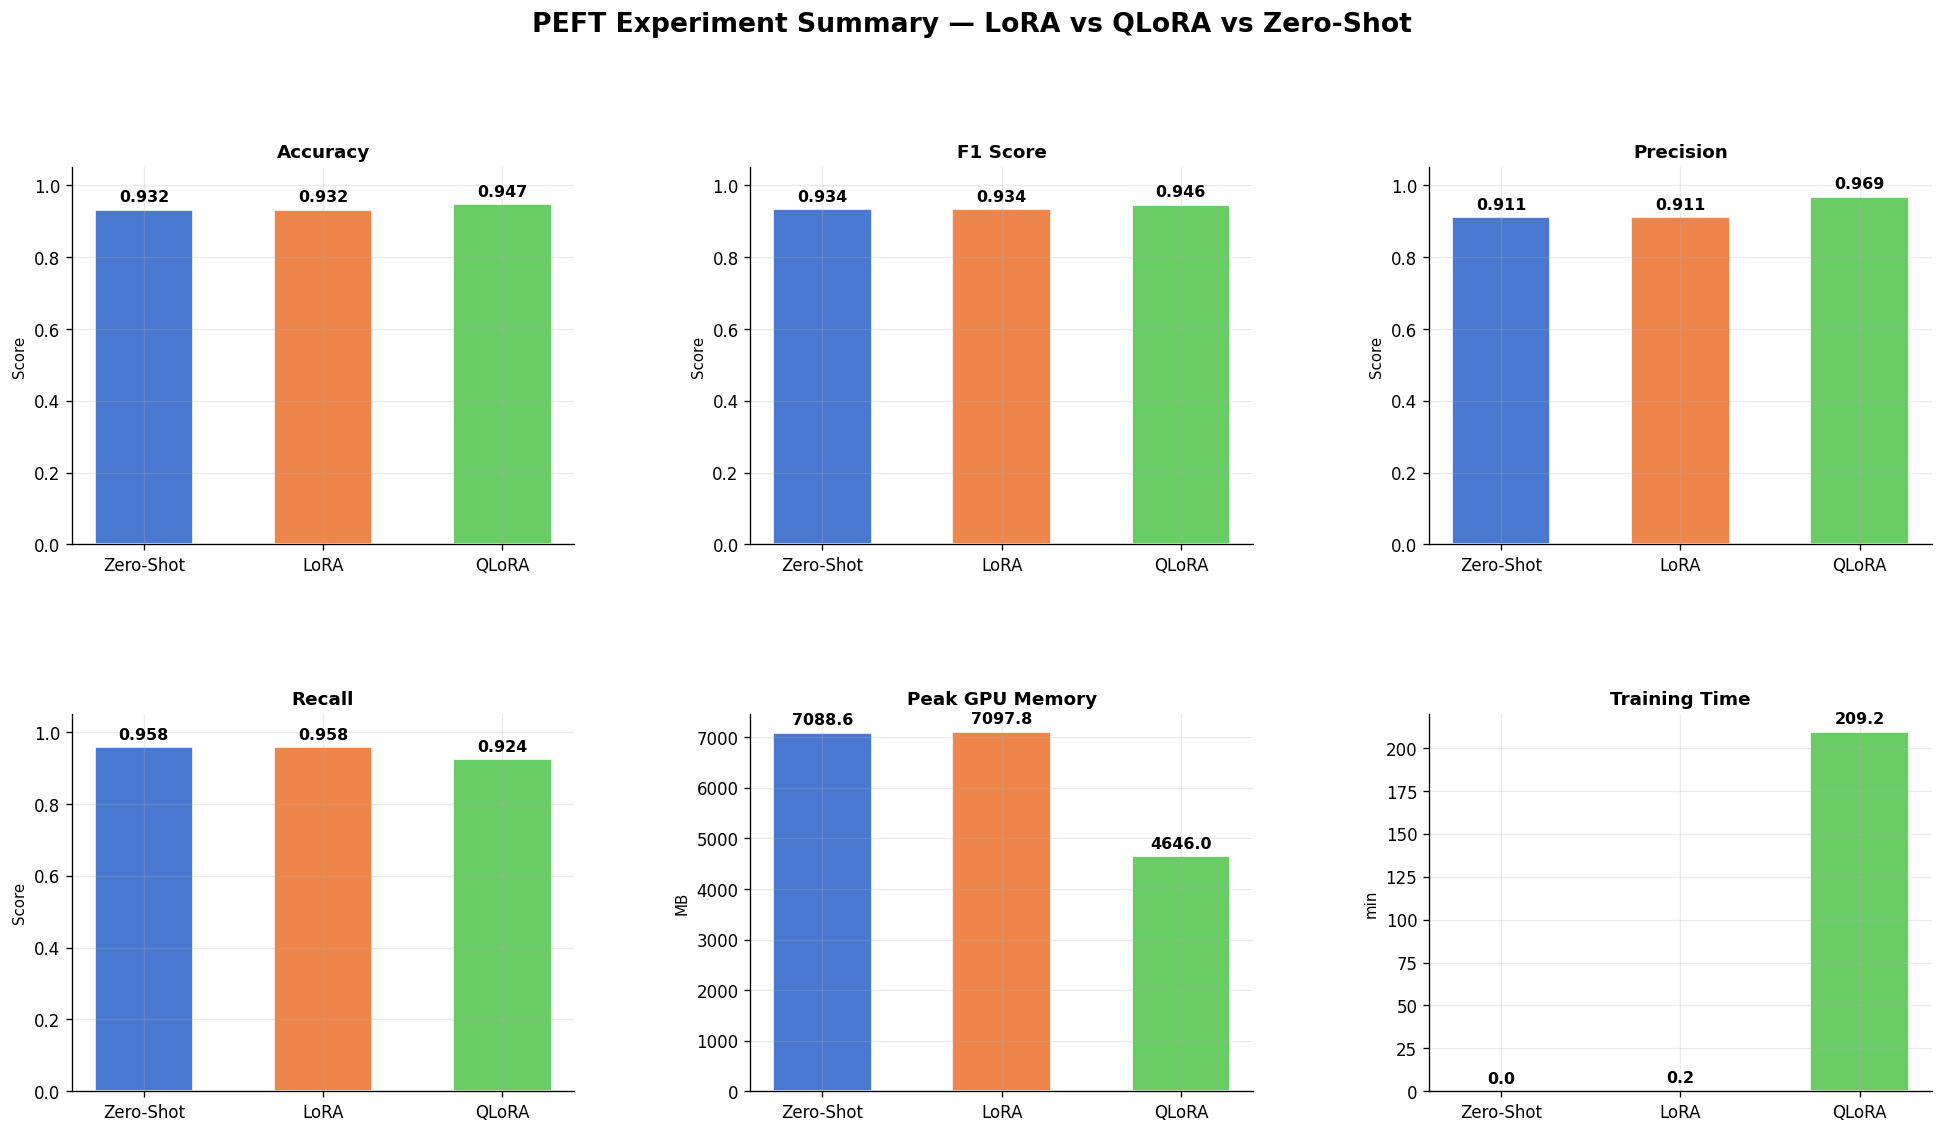

In [ ]:
fig = plt.figure(figsize=(20, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle(
    'PEFT Experiment Summary — LoRA vs QLoRA vs Zero-Shot',
    fontsize=16, fontweight='bold', y=1.01
)

panel_data = [
    ('accuracy'      , 'Accuracy'             , 'Score' ,  (0.0, 1.05)),
    ('f1'            , 'F1 Score'              , 'Score' ,  (0.0, 1.05)),
    ('precision'     , 'Precision'             , 'Score' ,  (0.0, 1.05)),
    ('recall'        , 'Recall'                , 'Score' ,  (0.0, 1.05)),
    ('gpu_memory_mb' , 'Peak GPU Memory'       , 'MB'    ,  None),
    ('train_time_s'  , 'Training Time'         , 'min'   ,  None),
]

for idx, (key, title, ylabel, ylim) in enumerate(panel_data):
    row, col = divmod(idx, 3)
    ax = fig.add_subplot(gs[row, col])
    scale = 60 if key == 'train_time_s' else 1
    vals  = [results[m][key] / scale for m in methods]
    bars  = ax.bar(methods, vals, color=PALETTE, edgecolor='white', width=0.55)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=9)
    if ylim:
        ax.set_ylim(*ylim)
    ax.tick_params(axis='x', labelsize=10)
    for b, v in zip(bars, vals):
        fmt_v = f'{v:.3f}' if key in ('accuracy','f1','precision','recall') else f'{v:.1f}'
        ax.text(b.get_x()+b.get_width()/2,
                b.get_height() + max(vals)*0.015,
                fmt_v, ha='center', va='bottom', fontsize=9.5, fontweight='bold')

p = f'{OUT_DIR}/figures/master_summary.png'
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')
